# Fast tokenizers in the QA pipeline

We will now dive into the `question-answering` pipeline and see how to leverage the offsets to grab the answer to the question at hand from the context, a bit like we did for the grouped entities in the previous section. Then we will see how we can deal with very long contexts that end up being truncated. You can skip this section if you're not interested in the question answering task.

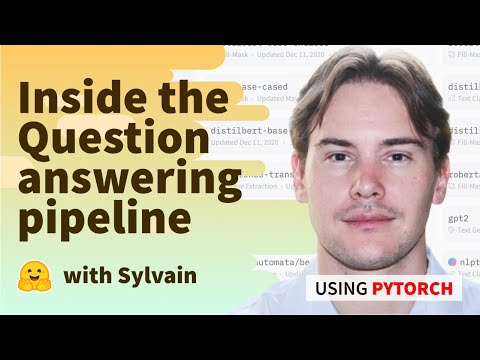

In [1]:
from IPython.display import YouTubeVideo

YouTubeVideo("_wxyB3j3mk4", width=800, height=450)

## Using the `question-answering` pipeline

As we saw in [Chapter 1](/course/chapter1), we can use the `question-answering` pipeline like this to get the answer to a question:

> Since `question-answering` pipeline is deprecated within huggingface eco-system, it is implemented here.

In [2]:
!uv pip install -qq matplotlib

In [3]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from transformers import AutoTokenizer, AutoModelForQuestionAnswering


class QuestionAnsweringPipeline:
    def __init__(
        self,
        model_name="deepset/roberta-base-squad2",
        device=None,
        max_answer_length=128,
        doc_stride=128,
        max_seq_len=512,
    ):
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.model = AutoModelForQuestionAnswering.from_pretrained(model_name)

        if device is None:
            device = "cuda" if torch.cuda.is_available() else "cpu"

        self.device = torch.device(device)
        self.model.to(self.device)
        self.model.eval()

        self.max_answer_length = max_answer_length
        self.doc_stride = doc_stride
        self.max_seq_len = max_seq_len

    @torch.inference_mode()
    def __call__(self, question: str, context: str):
        # ------------------------------------------------------------------
        # Tokenize with sliding windows (doc_stride)
        # ------------------------------------------------------------------
        inputs = self.tokenizer(
            question,
            context,
            stride=self.doc_stride,
            max_length=self.max_seq_len,
            return_offsets_mapping=True,
            return_overflowing_tokens=True,
            return_tensors="pt",
            truncation="only_second",
            padding="max_length",
        )

        offset_mappings = inputs.pop("offset_mapping")
        inputs.pop("overflow_to_sample_mapping", None)

        model_inputs = {k: v.to(self.device) for k, v in inputs.items()}

        # Forward pass on all window chunks at once
        outputs = self.model(**model_inputs)

        start_logits = outputs.start_logits.cpu().numpy()
        end_logits = outputs.end_logits.cpu().numpy()

        num_chunks = start_logits.shape[0]
        all_candidate_answers = []

        # Track masks for visualization dictionary output
        best_vis_masks = {}

        # ------------------------------------------------------------------
        # Process each context chunk independently
        # ------------------------------------------------------------------
        for chunk_idx in range(num_chunks):
            start_ = start_logits[chunk_idx].copy()
            end_ = end_logits[chunk_idx].copy()
            offset_mapping = offset_mappings[chunk_idx]
            sequence_ids = inputs.sequence_ids(chunk_idx)

            # Mask out non-context tokens (Question, CLS, SEP, PAD)
            context_mask = np.array([sid == 1 for sid in sequence_ids], dtype=bool)

            # Apply -10000.0 mask penalty to invalid tokens
            start_ = np.where(context_mask, start_, -10000.0)
            end_ = np.where(context_mask, end_, -10000.0)

            # Compute independent Softmax probabilities on start & end
            start_probs = np.exp(start_ - np.log(np.sum(np.exp(start_), axis=-1, keepdims=True)))
            end_probs = np.exp(end_ - np.log(np.sum(np.exp(end_), axis=-1, keepdims=True)))

            # Outer product matrix: score(start, end) = P_start[start] * P_end[end]
            outer_scores = np.outer(start_probs, end_probs)

            # Build valid span boundaries
            triangular_mask = np.triu(np.ones_like(outer_scores, dtype=bool))
            max_len_mask = np.tril(np.ones_like(outer_scores, dtype=bool), k=self.max_answer_length - 1)
            valid_span_mask = triangular_mask & max_len_mask

            # Filter valid candidate scores
            candidates = outer_scores * valid_span_mask

            # Best span inside this chunk
            best_idx = np.argmax(candidates)
            best_start, best_end = np.unravel_index(best_idx, candidates.shape)
            best_score = candidates[best_start, best_end]

            if best_score > 0.0:
                answer = self.tokenizer.decode(
                    inputs["input_ids"][chunk_idx, best_start : best_end + 1],
                    skip_special_tokens=True,
                ).strip()

                char_start = offset_mapping[best_start][0].item()
                char_end = offset_mapping[best_end][1].item()

                all_candidate_answers.append({
                    "score": float(best_score),
                    "start": char_start,
                    "end": char_end,
                    "answer": answer,
                    "visualization": {
                        "valid_range_mask": torch.from_numpy(triangular_mask),
                        "max_len_mask": torch.from_numpy(max_len_mask),
                        "valid_span_mask": torch.from_numpy(valid_span_mask),
                    },
                })

        # Return answer candidate with highest probability score across all chunks
        best_answer = max(all_candidate_answers, key=lambda x: x["score"])
        return best_answer

In [4]:
question_answerer = QuestionAnsweringPipeline()

question = "Which deep learning libraries back 🤗 Transformers?"

context = """
🤗 Transformers is backed by the three most popular deep learning libraries — Jax, PyTorch, and TensorFlow — with a seamless integration
between them. It's straightforward to train your models with one before loading them for inference with the other.
"""

out = question_answerer(question=question, context=context)
vis = out.pop("visualization")
out

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

{'score': 0.9686377048492432,
 'start': 78,
 'end': 106,
 'answer': 'Jax, PyTorch, and TensorFlow'}

---

We can simply return the answer but might give wrong answer.

I.e., 

1. `ix > jx`.
2. answer is very very long.
3. answer spanned in question area.

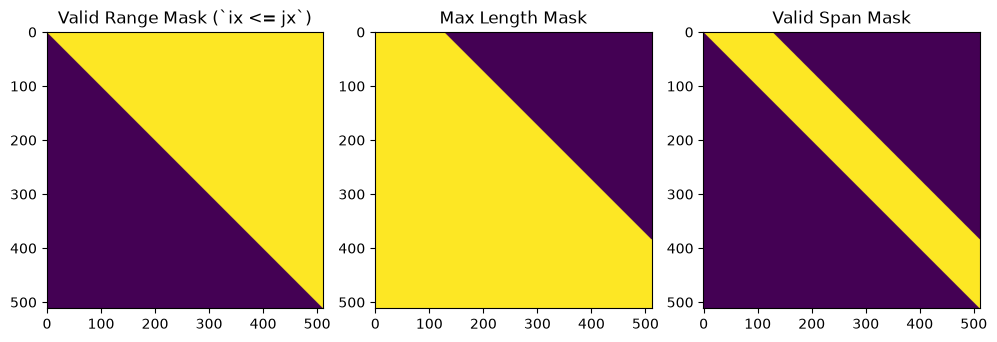

In [5]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=[10, 6])

ax1.set_title("Valid Range Mask (`ix <= jx`)")
ax1.imshow(vis['valid_range_mask'])

ax2.set_title("Max Length Mask")
ax2.imshow(vis['max_len_mask'])

ax3.set_title("Valid Span Mask")
ax3.imshow(vis['valid_span_mask'])

plt.tight_layout()
plt.show();

---

Unlike the other pipelines, which can't truncate and split texts that are longer than the maximum length accepted by the model (and thus may miss information at the end of a document), this pipeline can deal with very long contexts and will return the answer to the question even if it's at the end:

In [6]:
question_answerer = QuestionAnsweringPipeline()

question = "Which deep learning libraries back 🤗 Transformers?"
context = """
🤗 Transformers: State of the Art NLP

🤗 Transformers provides thousands of pretrained models to perform tasks on texts such as classification, information extraction,
question answering, summarization, translation, text generation and more in over 100 languages.
Its aim is to make cutting-edge NLP easier to use for everyone.

🤗 Transformers provides APIs to quickly download and use those pretrained models on a given text, fine-tune them on your own datasets and
then share them with the community on our model hub. At the same time, each python module defining an architecture is fully standalone and
can be modified to enable quick research experiments.

Why should I use transformers?

1. Easy-to-use state-of-the-art models:
  - High performance on NLU and NLG tasks.
  - Low barrier to entry for educators and practitioners.
  - Few user-facing abstractions with just three classes to learn.
  - A unified API for using all our pretrained models.
  - Lower compute costs, smaller carbon footprint:

2. Researchers can share trained models instead of always retraining.
  - Practitioners can reduce compute time and production costs.
  - Dozens of architectures with over 10,000 pretrained models, some in more than 100 languages.

3. Choose the right framework for every part of a model's lifetime:
  - Train state-of-the-art models in 3 lines of code.
  - Move a single model between TF2.0/PyTorch frameworks at will.
  - Seamlessly pick the right framework for training, evaluation and production.

4. Easily customize a model or an example to your needs:
  - We provide examples for each architecture to reproduce the results published by its original authors.
  - Model internals are exposed as consistently as possible.
  - Model files can be used independently of the library for quick experiments.

🤗 Transformers is backed by the three most popular deep learning libraries — Jax, PyTorch and TensorFlow — with a seamless integration
between them. It's straightforward to train your models with one before loading them for inference with the other.
"""

out = question_answerer(question=question, context=context)
vis = out.pop("visualization")
out

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

{'score': 0.9357251524925232,
 'start': 1892,
 'end': 1919,
 'answer': 'Jax, PyTorch and TensorFlow'}

---

Let's see how it does all of this!

> ✏️ Try it out! Use the best scores you computed earlier to show the five most likely answers. To check your results, go back to the first pipeline and pass in top_k=5 when calling it.

## What we learnt?

We learnt following topics in this chapter.

1. Question Answering using creating class like `pipeline()`.
2. Question Answering using `AutoModelForQuestionAnswering` model.
3. Handling long sequences.